# 25 Hz CAN Session Exploration

In [7]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "matplotlib is required to plot the six CAN signals in this notebook."
    ) from exc


def resolve_project_root(start: Path | None = None) -> Path:
    search_start = (start or Path.cwd()).resolve()
    for candidate in (search_start, *search_start.parents):
        if (candidate / "data" / "can_data_25hz").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate the project root. Expected to find 'data/can_data_25hz'."
    )


PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from traceability.data import CAN_COLUMNS, load_can_session, resolve_session_path

DATA_ROOT = PROJECT_ROOT / "data" / "can_data_25hz"
SAMPLING_HZ = 25.0


def discover_session_ids(data_root: Path = DATA_ROOT) -> list[str]:
    return sorted(path.stem for path in data_root.glob("*.npy") if path.is_file())


def format_duration(num_steps: int, sampling_hz: float = SAMPLING_HZ) -> str:
    total_centiseconds = round((num_steps / sampling_hz) * 100)
    minutes, remainder = divmod(total_centiseconds, 6000)
    seconds, centiseconds = divmod(remainder, 100)
    return f"{minutes:02d}:{seconds:02d}:{centiseconds:02d}"


def load_session_bundle(session_id: str, data_root: Path = DATA_ROOT) -> dict[str, object]:
    session_id = str(session_id).strip()
    session_path = resolve_session_path(session_id=session_id, data_root=data_root)
    session = load_can_session(session_path=session_path, session_id=session_id)
    return {
        "session_id": session.session_id,
        "session_path": session_path,
        "session_array": session.values,
    }


def build_session_summary(
    session_bundle: dict[str, object], sampling_hz: float = SAMPLING_HZ
) -> dict[str, object]:
    session_array = session_bundle["session_array"]
    num_steps = int(session_array.shape[0])
    return {
        "session_id": session_bundle["session_id"],
        "num_timesteps_25hz": num_steps,
        "duration_mm_ss_cs": format_duration(num_steps, sampling_hz=sampling_hz),
        "duration_seconds": round(num_steps / sampling_hz, 2),
        "num_signals": int(session_array.shape[1]),
    }


def build_array_metadata(session_bundle: dict[str, object]) -> dict[str, object]:
    session_array = session_bundle["session_array"]
    session_path = session_bundle["session_path"]
    file_size_bytes = int(session_path.stat().st_size)
    return {
        "shape": tuple(int(value) for value in session_array.shape),
        "dtype": str(session_array.dtype),
        "array_size_bytes": int(session_array.nbytes),
        "array_size_mb": round(session_array.nbytes / (1024 ** 2), 3),
        "file_size_bytes": file_size_bytes,
        "file_size_mb": round(file_size_bytes / (1024 ** 2), 3),
        "signal_names": list(CAN_COLUMNS),
    }


def print_mapping(title: str, values: dict[str, object]) -> None:
    print(title)
    print("-" * len(title))
    for key, value in values.items():
        print(f"{key}: {value}")


def plot_session_signals(
    session_bundle: dict[str, object], sampling_hz: float = SAMPLING_HZ
) -> None:
    session_id = session_bundle["session_id"]
    session_array = session_bundle["session_array"]
    time_axis_seconds = np.arange(session_array.shape[0], dtype=np.float64) / sampling_hz

    fig, axes = plt.subplots(len(CAN_COLUMNS), 1, figsize=(16, 14), sharex=True)
    fig.suptitle(f"Session {session_id} | 6 CAN signals over time", fontsize=14)

    for index, signal_name in enumerate(CAN_COLUMNS):
        axes[index].plot(time_axis_seconds, session_array[:, index], linewidth=0.8)
        axes[index].set_ylabel(signal_name)
        axes[index].grid(alpha=0.3)

    axes[-1].set_xlabel("Time (seconds)")
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()


## 1. Choose a session id

Run this cell and enter the 12-digit driving session id you want to explore.
If you press Enter without typing anything, the notebook will use the first available 25 Hz session id as the default.

In [8]:
available_session_ids = discover_session_ids()
print(f"Discovered {len(available_session_ids)} 25 Hz sessions in {DATA_ROOT}")
print("Example session ids:", ", ".join(available_session_ids[:10]))

default_session_id = available_session_ids[0] if available_session_ids else None
SESSION_ID = input(
    f"Enter a driving session id from data/can_data_25hz [{default_session_id}]: "
).strip() or default_session_id

if not SESSION_ID:
    raise ValueError("No session id was provided and no default session id is available.")

print(f"Selected session id: {SESSION_ID}")


Discovered 137 25 Hz sessions in C:\Users\emb-vishhbk\OneDrive - Embitel Technologies India Private Limited\Desktop\Project-T-Hybrid\data\can_data_25hz
Example session ids: 201702271017, 201702271123, 201702271136, 201702271438, 201702271632, 201702281017, 201702281511, 201702281709, 201703011016, 201703061033
Selected session id: 201704141639


## 2. Session overview

In [9]:
if "SESSION_ID" not in globals():
    raise NameError("Run the session input cell before loading a session.")

SESSION_BUNDLE = load_session_bundle(SESSION_ID)
SESSION_SUMMARY = build_session_summary(SESSION_BUNDLE)
print_mapping("Session Overview", SESSION_SUMMARY)


Session Overview
----------------
session_id: 201704141639
num_timesteps_25hz: 35203
duration_mm_ss_cs: 23:28:12
duration_seconds: 1408.12
num_signals: 6


## 3. Array metadata

In [10]:
if "SESSION_BUNDLE" not in globals():
    raise NameError("Run the session overview cell before requesting array metadata.")

SESSION_METADATA = build_array_metadata(SESSION_BUNDLE)
print_mapping("Array Metadata", SESSION_METADATA)


Array Metadata
--------------
shape: (35203, 6)
dtype: float64
array_size_bytes: 1689744
array_size_mb: 1.611
file_size_bytes: 1689824
file_size_mb: 1.612
signal_names: ['pedalangle', 'pedalpressure', 'steer_angle', 'steer_speed', 'speed', 'yaw']


## 4. Plot the six signals

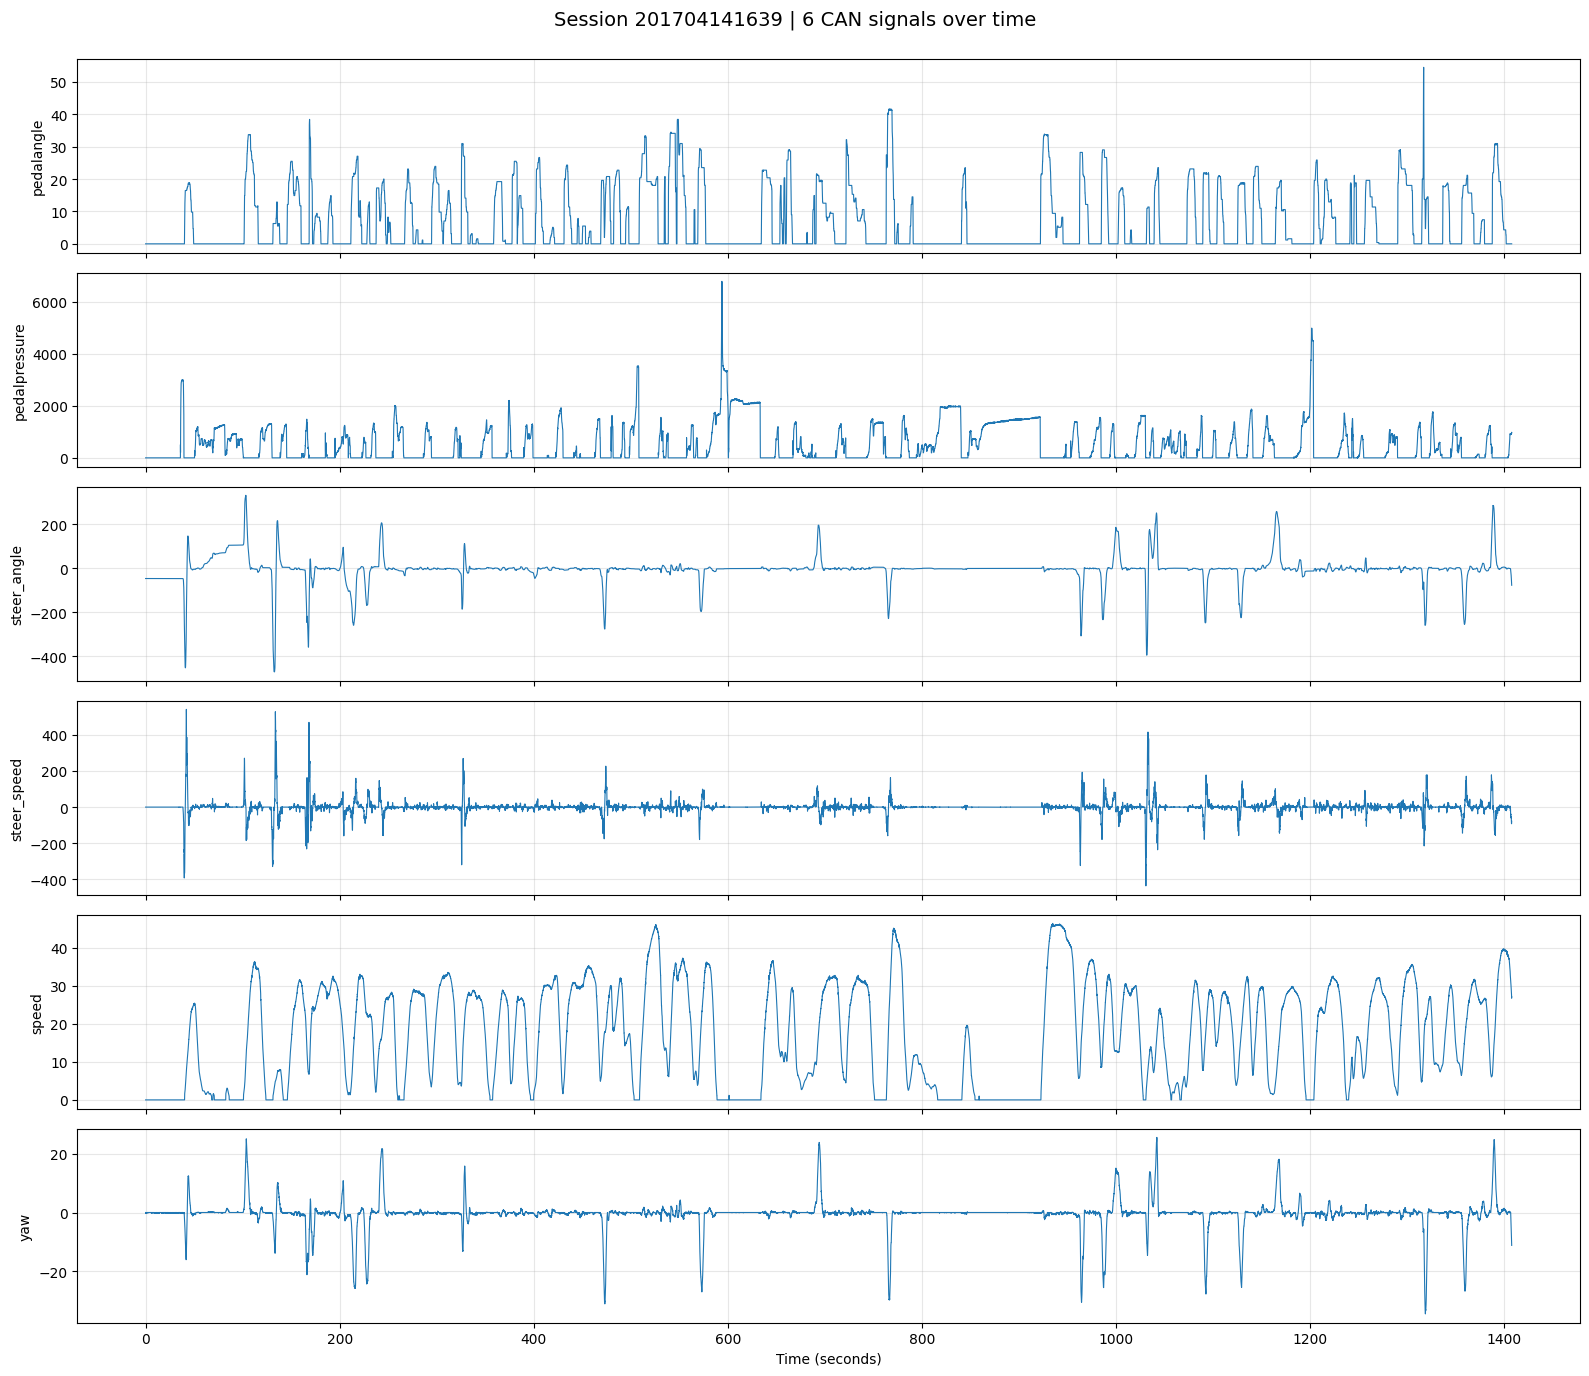

In [11]:
if "SESSION_BUNDLE" not in globals():
    raise NameError("Run the session overview cell before plotting the session signals.")

plot_session_signals(SESSION_BUNDLE)
